# Native Land-Cover Classification Polygon CRUD

This notebook edits a disposable HEC-RAS land-cover sidecar exclusively
through the public native RASMapper polygon API. It demonstrates list,
add, update, delete, one-member `MultiPolygon` normalization, true
multipart and interior-ring rejection, durable backups, native geometry
recomputation, geometry base/region override precedence, and a complete
hydraulic solve.

Acceptance is based on the final solver-owned Manning and WSE arrays,
not on the sidecar write alone.


## Supported contract

| Operation | Canonical API | Contract |
|---|---|---|
| Read | `RasMap.list_land_classification_polygons()` | One row per persisted polygon |
| Add | `RasMap.add_land_classification_polygon()` | Existing class only; native save/readback; durable backup |
| Update | `RasMap.update_land_classification_polygon()` | One hole-free polygon and existing class persist by index |
| Delete | `RasMap.delete_land_classification_polygon()` | Native removal; class table remains intact |
| Reject unsupported topology | Add/update normalization | True multipart and interior rings fail before backup/native mutation |
| Recompute | `RasMap.recompute_property_tables()` | HEC-RAS resamples the sidecar into geometry tables |
| Verify | `RasCmdr.compute_plan()` | Required final arrays and completed hydraulic solve |

Raw Shapely coordinates are interpreted in the sidecar CRS. A
one-member, hole-free `MultiPolygon` is normalized to its polygon. True
multipart geometry and interior rings fail before mutation. HEC-RAS
6.0 through 7.0.1 can persist a ring but its classification resampler
fills the hole, so the public mutation API does not pretend the topology
is supported. HEC-RAS 5.x users should use durable geometry Manning
regions because this sidecar polygon API is qualified for HEC-RAS 6.x
and 7.0.x.


In [1]:
# ruff: noqa: E402
from pathlib import Path
import sys
import logging
import hashlib
import warnings

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (
        (candidate / "ras_commander" / "__init__.py").exists()
        and (candidate / "examples").exists()
    ):
        REPO_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate the ras-commander checkout")
repo_root_string = str(REPO_ROOT)
if repo_root_string in sys.path:
    sys.path.remove(repo_root_string)
sys.path.insert(0, repo_root_string)

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from shapely.geometry import LineString, MultiPolygon, Polygon, box

import ras_commander
from ras_commander import RasCmdr, RasExamples, RasMap, init_ras_project
from ras_commander.geom import GeomLandCover, GeomLateral
from ras_commander.hdf import (
    HdfBase,
    HdfBndry,
    HdfLandCover,
    HdfMesh,
    HdfPlan,
    HdfResultsBreach,
    HdfResultsMesh,
    HdfResultsPlan,
)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as source:
        for block in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def backup_glob_state(layer_hdf_path):
    layer_hdf_path = Path(layer_hdf_path)
    pattern = f"{layer_hdf_path.stem}*.backup{layer_hdf_path.suffix}"
    return {
        candidate.name: (
            candidate.stat().st_size,
            sha256_file(candidate),
        )
        for candidate in sorted(layer_hdf_path.parent.glob(pattern))
    }

# Some mixed GDAL/PROJ Windows environments emit this known pyproj
# database-location warning even when the authoritative HDF CRS reads
# successfully. Suppress only that exact warning family; all other
# geospatial and solver warnings remain visible.
warnings.filterwarnings(
    "ignore",
    message=r".*proj_create_from_database.*proj\.db.*",
    category=Warning,
    module=r"pyproj(\..*)?",
)

logging.getLogger("ras_commander").setLevel(logging.WARNING)
for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 180,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)

RAS_VERSION = "7.0"
PLAN_NUMBER = "03"
GEOMETRY_NUMBER = "09"
MESH_NAME = "BaldEagleCr"
FINAL_CLASS = "Evergreen Forest"
TRANSIENT_CLASS = "Barren Land Rock-Sand-Clay"
DELETION_CLASS = "Developed, Open Space"
RAS_COMMANDER_VERSION = ras_commander.__version__
RAS_COMMANDER_REVISION = next(
    (
        str(getattr(ras_commander, attribute))
        for attribute in ("__commit__", "__git_revision__")
        if getattr(ras_commander, attribute, None)
    ),
    "not exposed by package metadata",
)

WORK_ROOT = REPO_ROOT / "working" / "notebook_runs" / "CLB-903" / "213"
WORK_ROOT.mkdir(parents=True, exist_ok=True)


## Project and hydraulic context

Plan 03 is an unsteady, single-2D-area Bald Eagle Creek dam-break
simulation. Its forcing comprises one upstream flow hydrograph, two
downstream normal-depth lines, and a gate-opening schedule. There is
no stage hydrograph. Independent disposable project copies preserve a
true baseline for final-array comparison.

After the baseline solve, public geometry APIs supply the three mapped
boundary-condition lines and the 41-point `Sayers Dam` connection.
They are plotted over the registered `Terrain50` companion raster with
the proposed override footprint. The setup cell suppresses only the
known pyproj `proj.db` location warning; the authoritative CRS is still
read and displayed from HDF, and all other warnings remain visible.


In [2]:
available_examples = RasExamples.get_example_projects(RAS_VERSION)
baseline_path = Path(
    RasExamples.extract_project(
        "BaldEagleCrkMulti2D",
        output_path=WORK_ROOT,
        suffix="213_baseline",
    )
)
modified_path = Path(
    RasExamples.extract_project(
        "BaldEagleCrkMulti2D",
        output_path=WORK_ROOT,
        suffix="213_modified",
    )
)
baseline_ras = init_ras_project(
    baseline_path,
    RAS_VERSION,
    ras_object="new",
    accept_tcu=True,
)
modified_ras = init_ras_project(
    modified_path,
    RAS_VERSION,
    ras_object="new",
    accept_tcu=True,
)

baseline_plan = baseline_ras.plan_df.loc[
    baseline_ras.plan_df["plan_number"] == PLAN_NUMBER
].iloc[0]
modified_geom = modified_ras.geom_df.loc[
    modified_ras.geom_df["geom_number"] == GEOMETRY_NUMBER
].iloc[0]
baseline_geom = baseline_ras.geom_df.loc[
    baseline_ras.geom_df["geom_number"] == GEOMETRY_NUMBER
].iloc[0]
baseline_plan_hdf = (
    baseline_path / f"{baseline_ras.project_name}.p{PLAN_NUMBER}.hdf"
)
modified_plan_hdf = (
    modified_path / f"{modified_ras.project_name}.p{PLAN_NUMBER}.hdf"
)
modified_geometry_hdf = Path(modified_geom["hdf_path"])
modified_geometry_path = Path(modified_geom["full_path"])
baseline_geometry_hdf = Path(baseline_geom["hdf_path"])
baseline_geometry_path = Path(baseline_geom["full_path"])

flow_number = str(baseline_plan["unsteady_number"]).zfill(2)

context = pd.DataFrame(
    [
        {"item": "requested HEC-RAS runtime", "value": RAS_VERSION},
        {
            "item": "plan Program Version",
            "value": baseline_plan.get(
                "Program Version",
                "not available",
            ),
        },
        {
            "item": "ras-commander version",
            "value": RAS_COMMANDER_VERSION,
        },
        {
            "item": "ras-commander revision",
            "value": RAS_COMMANDER_REVISION,
        },
        {"item": "plan", "value": f"p{PLAN_NUMBER}: {baseline_plan['Plan Title']}"},
        {"item": "geometry", "value": f"g{GEOMETRY_NUMBER}"},
        {
            "item": "unsteady flow",
            "value": f"u{flow_number}",
        },
        {"item": "2D flow area", "value": MESH_NAME},
        {"item": "simulation period", "value": baseline_plan["Simulation Date"]},
        {"item": "computation interval", "value": baseline_plan["Computation Interval"]},
        {"item": "mapping interval", "value": baseline_plan["Mapping Interval"]},
        {"item": "model description", "value": baseline_plan["description"]},
    ]
)
display(context)

boundary_context = baseline_ras.boundaries_df.loc[
    baseline_ras.boundaries_df["unsteady_number"] == flow_number,
    [
        "bc_type",
        "hydrograph_type",
        "river_reach_name",
        "river_station",
        "storage_area_name",
        "area_2d",
        "bc_line_name",
    ],
].drop_duplicates()
boundary_types = boundary_context["bc_type"].fillna("")
hydrograph_types = boundary_context["hydrograph_type"].fillna("")
assert int(boundary_types.eq("Normal Depth").sum()) == 2
assert int(boundary_types.eq("Flow Hydrograph").sum()) == 1
assert int(boundary_types.eq("Gate Opening").sum()) == 1
upstream_flow_boundary = boundary_context.loc[
    boundary_types.eq("Flow Hydrograph")
].iloc[0]
assert upstream_flow_boundary["area_2d"] == MESH_NAME
assert upstream_flow_boundary["bc_line_name"] == "Upstream Inflow"
assert not boundary_types.str.contains(
    "Stage Hydrograph", case=False
).any()
assert not hydrograph_types.str.contains(
    "Stage Hydrograph", case=False
).any()
display(boundary_context.reset_index(drop=True))

# Normalize the baseline through the same native association and
# property-table path used for the modified condition.
baseline_landcover = Path(
    RasMap.list_landcover_layers(
        baseline_path, ras_object=baseline_ras
    ).iloc[0]["resolved_path"]
)
baseline_terrain = Path(
    RasMap.list_terrain_layers(
        baseline_path, ras_object=baseline_ras
    ).iloc[0]["resolved_path"]
)
baseline_infiltration = Path(
    RasMap.list_infiltration_layers(
        baseline_path, ras_object=baseline_ras
    ).iloc[0]["resolved_path"]
)
baseline_association_result = RasMap.associate_geometry_layers(
    baseline_path,
    baseline_geometry_hdf,
    landcover_hdf_path=baseline_landcover,
    infiltration_hdf_path=baseline_infiltration,
    terrain_hdf_path=baseline_terrain,
    hecras_version=RAS_VERSION,
    ras_object=baseline_ras,
)
baseline_recomputed_hdf = RasMap.recompute_property_tables(
    baseline_path,
    baseline_geometry_hdf,
    hecras_version=RAS_VERSION,
    audit_mannings=True,
    ras_object=baseline_ras,
)
assert baseline_recomputed_hdf == baseline_geometry_hdf


,item,value
0,requested HEC-RAS runtime,7.0
1,plan Program Version,5.04
2,ras-commander version,0.98.0
3,ras-commander revision,not exposed by package metadata
4,plan,p03: Single 2D Area - Internal Dam Structure
5,geometry,g09
6,unsteady flow,u13
7,2D flow area,BaldEagleCr
8,simulation period,"01JAN1999,1200,04JAN1999,1200"
9,computation interval,30SEC


,bc_type,hydrograph_type,river_reach_name,river_station,storage_area_name,area_2d,bc_line_name
0,Normal Depth,NaN,,,,BaldEagleCr,DSNormalDepth
1,Normal Depth,NaN,,,,BaldEagleCr,DS2NormalD
2,Flow Hydrograph,Flow Hydrograph,,,,BaldEagleCr,Upstream Inflow
3,Gate Opening,NaN,,,,,


## Baseline hydraulic solve

The baseline run must complete and contain both final cell and face
Manning arrays. This prevents a successful process exit from standing
in for the requested solver evidence. Exact HDF build, flow filename,
CRS, and mesh-population metadata are read only after that HDF exists.


2026-07-25 15:07:39 - rasterio._err - WARNING - CPLE_AppDefined:PROJ: proj_create_from_database: C:\Program Files (x86)\HEC\HEC-RAS\7.0.1\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


2026-07-25 15:07:39 - rasterio._err - WARNING - CPLE_AppDefined:PROJ: proj_create_from_name: C:\Program Files (x86)\HEC\HEC-RAS\7.0.1\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


2026-07-25 15:07:40 - rasterio._err - WARNING - CPLE_AppDefined:PROJ: proj_create_from_database: C:\Program Files (x86)\HEC\HEC-RAS\7.0.1\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


2026-07-25 15:07:40 - rasterio._err - WARNING - CPLE_AppDefined:PROJ: proj_create_from_name: C:\Program Files (x86)\HEC\HEC-RAS\7.0.1\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


,hdf_path,mesh_name,complete_geometry,landcover_filename,landcover_layer_name,cell_value_count,cell_distinct_count,cell_distinct_values,face_value_count,face_distinct_count,face_distinct_values,missing_expected_values,passed,failure_reason
0,C:\Users\bill\.config\superpowers\worktrees\ra...,BaldEagleCr,True,.\Land Classification\LandCover.hdf,LandCover,19597,10,"(0.029999999329447746, 0.03500000014901161, 0....",434012,10,"(0.029999999329447746, 0.03500000014901161, 0....",(),True,


,exact HDF build,flow file,project CRS,mesh cell centers,reconstructable cell polygons,solution,run time window
0,HEC-RAS 7.0 April 2026,BaldEagleDamBrk.u13,EPSG:2271,19597,18066,Unsteady Finished Successfully,25JUL2026 15:04:53 to 25JUL2026 15:07:36


,registered terrain,companion raster,mapped BC lines,Sayers Dam connection vertices
0,Terrain50,Terrain50.vrt,3,41


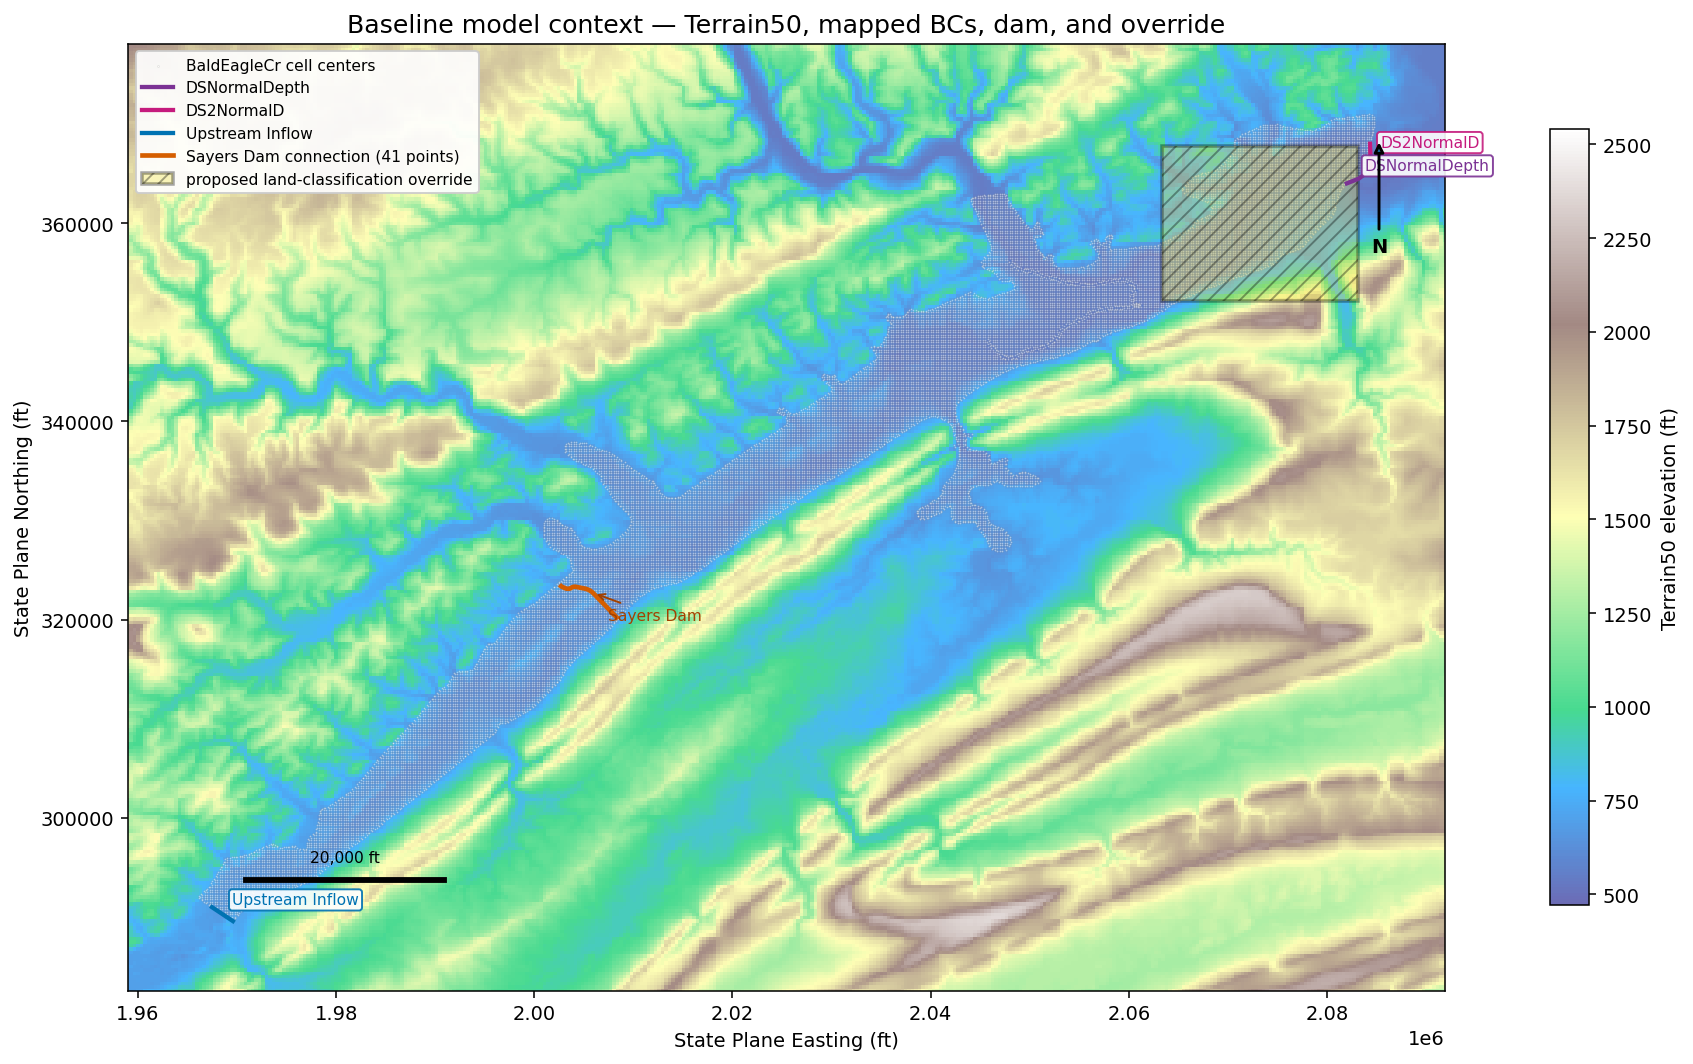

In [3]:
baseline_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=baseline_ras,
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert baseline_result.success, "Baseline HEC-RAS computation failed."
assert baseline_result.completion_verified is True

baseline_cells = HdfLandCover.get_preprocessed_mannings_n(
    baseline_plan_hdf,
    mesh_name=MESH_NAME,
).rename(columns={"mannings_n": "baseline_n"})
baseline_wse = HdfResultsMesh.get_mesh_max_ws(baseline_plan_hdf)
baseline_faces = HdfMesh.get_mesh_face_property_tables(
    baseline_plan_hdf
)[MESH_NAME].sort_values(["Face ID", "Elevation"]).reset_index(drop=True)
baseline_audit = HdfLandCover.audit_final_mannings_n(
    baseline_plan_hdf,
    mesh_name=MESH_NAME,
    tolerance=1.0e-4,
)
plan_hdf_information = HdfPlan.get_plan_information(
    baseline_plan_hdf
)
project_crs = HdfBase.get_projection(baseline_plan_hdf)
postcompute_cell_points = HdfMesh.get_mesh_cell_points(
    baseline_plan_hdf
)
postcompute_cell_points = postcompute_cell_points.loc[
    postcompute_cell_points["mesh_name"] == MESH_NAME
]
postcompute_cell_polygons = HdfMesh.get_mesh_cell_polygons(
    baseline_plan_hdf
)
postcompute_cell_polygons = postcompute_cell_polygons.loc[
    postcompute_cell_polygons["mesh_name"] == MESH_NAME
]
assert len(postcompute_cell_points) == 19_597
assert len(postcompute_cell_polygons) == 18_066
baseline_hdf_info = HdfResultsPlan.get_unsteady_info(
    baseline_plan_hdf
)
baseline_hdf_summary = HdfResultsPlan.get_unsteady_summary(
    baseline_plan_hdf
)
baseline_exact_hdf_build = str(
    baseline_hdf_info.iloc[0]["Program Version"]
)
assert baseline_exact_hdf_build == "HEC-RAS 7.0 April 2026"

bc_lines = HdfBndry.get_bc_lines(baseline_plan_hdf)
assert len(bc_lines) == 3
assert set(bc_lines["Name"]) == {
    "DSNormalDepth",
    "DS2NormalD",
    "Upstream Inflow",
}
assert bc_lines.geometry.notna().all()

connection_coordinates = GeomLateral.get_connection_line_coords(
    baseline_geometry_path,
    "Sayers Dam",
)
assert list(connection_coordinates.columns) == ["X", "Y"]
assert len(connection_coordinates) == 41
connection_line = LineString(
    connection_coordinates[["X", "Y"]].to_numpy()
)
assert len(connection_line.coords) == 41

baseline_terrain_layers = RasMap.list_terrain_layers(
    baseline_path,
    ras_object=baseline_ras,
)
assert len(baseline_terrain_layers) == 1
assert baseline_terrain_layers.iloc[0]["name"] == "Terrain50"
registered_terrain_hdf = Path(
    baseline_terrain_layers.iloc[0]["resolved_path"]
)
assert registered_terrain_hdf == baseline_terrain
terrain_companion_vrt = registered_terrain_hdf.with_suffix(".vrt")
assert terrain_companion_vrt.is_file()
with rasterio.open(terrain_companion_vrt) as terrain_dataset:
    preview_scale = max(
        terrain_dataset.width,
        terrain_dataset.height,
    ) / 900
    preview_height = max(
        1,
        round(terrain_dataset.height / preview_scale),
    )
    preview_width = max(
        1,
        round(terrain_dataset.width / preview_scale),
    )
    terrain_preview = terrain_dataset.read(
        1,
        out_shape=(preview_height, preview_width),
        masked=True,
    )
    terrain_extent = (
        terrain_dataset.bounds.left,
        terrain_dataset.bounds.right,
        terrain_dataset.bounds.bottom,
        terrain_dataset.bounds.top,
    )
    terrain_raster_crs = terrain_dataset.crs
assert terrain_raster_crs is not None

context_override_polygon = box(
    2_063_347.2881,
    352_125.3883,
    2_083_124.6947,
    367_770.6226,
)
assert context_override_polygon.is_valid

display(baseline_audit)
display(
    pd.DataFrame(
        [
            {
                "exact HDF build": baseline_exact_hdf_build,
                "flow file": plan_hdf_information["Flow Filename"],
                "project CRS": str(project_crs),
                "mesh cell centers": len(postcompute_cell_points),
                "reconstructable cell polygons": len(
                    postcompute_cell_polygons
                ),
                "solution": baseline_hdf_summary.iloc[0]["Solution"],
                "run time window": baseline_hdf_summary.iloc[0][
                    "Run Time Window"
                ],
            }
        ]
    )
)
display(
    pd.DataFrame(
        [
            {
                "registered terrain": registered_terrain_hdf.stem,
                "companion raster": terrain_companion_vrt.name,
                "mapped BC lines": len(bc_lines),
                "Sayers Dam connection vertices": len(
                    connection_coordinates
                ),
            }
        ]
    )
)

fig, context_ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True,
)
terrain_image = context_ax.imshow(
    terrain_preview,
    extent=terrain_extent,
    origin="upper",
    cmap="terrain",
    alpha=0.72,
)
fig.colorbar(
    terrain_image,
    ax=context_ax,
    shrink=0.75,
    label="Terrain50 elevation (ft)",
)
postcompute_cell_points.plot(
    ax=context_ax,
    color="white",
    edgecolor="0.25",
    linewidth=0.1,
    markersize=1.0,
    alpha=0.45,
    label=f"{MESH_NAME} cell centers",
)
boundary_colors = {
    "Upstream Inflow": "#0072B2",
    "DSNormalDepth": "#7B3294",
    "DS2NormalD": "#C51B7D",
}
for boundary in bc_lines.itertuples(index=False):
    color = boundary_colors[boundary.Name]
    x_values, y_values = boundary.geometry.xy
    context_ax.plot(
        x_values,
        y_values,
        color=color,
        linewidth=2.2,
        label=boundary.Name,
    )
    midpoint = boundary.geometry.interpolate(0.5, normalized=True)
    context_ax.annotate(
        boundary.Name,
        xy=(midpoint.x, midpoint.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color=color,
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "white",
            "edgecolor": color,
            "alpha": 0.9,
        },
    )
connection_x, connection_y = connection_line.xy
context_ax.plot(
    connection_x,
    connection_y,
    color="#D55E00",
    linewidth=2.4,
    label="Sayers Dam connection (41 points)",
)
connection_midpoint = connection_line.interpolate(
    0.5,
    normalized=True,
)
context_ax.annotate(
    "Sayers Dam",
    xy=(connection_midpoint.x, connection_midpoint.y),
    xytext=(8, -14),
    textcoords="offset points",
    fontsize=8,
    color="#A34100",
    arrowprops={"arrowstyle": "->", "color": "#A34100"},
)
override_x, override_y = context_override_polygon.exterior.xy
context_ax.fill(
    override_x,
    override_y,
    facecolor="#F0E442",
    edgecolor="black",
    linewidth=1.8,
    alpha=0.35,
    hatch="///",
    label="proposed land-classification override",
)

model_minx, model_miny, model_maxx, model_maxy = (
    postcompute_cell_points.total_bounds
)
map_padding = 0.06 * max(
    model_maxx - model_minx,
    model_maxy - model_miny,
)
context_ax.set_xlim(model_minx - map_padding, model_maxx + map_padding)
context_ax.set_ylim(model_miny - map_padding, model_maxy + map_padding)
scale_length_ft = 20_000
scale_x = model_minx + 0.04 * (model_maxx - model_minx)
scale_y = model_miny + 0.05 * (model_maxy - model_miny)
context_ax.plot(
    [scale_x, scale_x + scale_length_ft],
    [scale_y, scale_y],
    color="black",
    linewidth=3,
)
context_ax.text(
    scale_x + scale_length_ft / 2,
    scale_y + 1_500,
    "20,000 ft",
    ha="center",
    va="bottom",
    fontsize=8,
)
context_ax.annotate(
    "N",
    xy=(0.95, 0.90),
    xytext=(0.95, 0.78),
    xycoords="axes fraction",
    ha="center",
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "linewidth": 1.5},
)
context_ax.set_title(
    "Baseline model context — Terrain50, mapped BCs, dam, and override"
)
context_ax.set_xlabel("State Plane Easting (ft)")
context_ax.set_ylabel("State Plane Northing (ft)")
context_ax.set_aspect("equal")
context_ax.legend(loc="upper left", framealpha=0.92)
plt.show()


## Discover the sidecar, geometry overrides, and supported polygon

The final polygon targets an existing `Evergreen Forest` class so the
operation changes only the classification override footprint. The
sidecar class value is not necessarily the final solver value: the
geometry's durable base and regional `LCMann` tables take precedence
during preprocessing. No class values or custom HDF datasets are
authored.


In [4]:
landcover_layers = RasMap.list_landcover_layers(
    modified_path, ras_object=modified_ras
)
assert not landcover_layers.empty
sidecar_hdf = Path(landcover_layers.iloc[0]["resolved_path"])
class_table = HdfLandCover.get_landcover_raster_map(sidecar_hdf)
final_class_row = class_table.loc[
    class_table["class_name"] == FINAL_CLASS
].iloc[0]
sidecar_class_n = float(final_class_row["mannings_n"])
base_mannings = GeomLandCover.get_base_mannings_n(
    modified_geometry_path
)
region_mannings = GeomLandCover.get_region_mannings_n(
    modified_geometry_path
)
target_base_n = float(
    base_mannings.loc[
        base_mannings["Land Cover Name"] == FINAL_CLASS,
        "Base Mannings n Value",
    ].iloc[0]
)
target_region_n = sorted(
    region_mannings.loc[
        region_mannings["Land Cover Name"] == FINAL_CLASS,
        "MainChannel",
    ].astype(float).unique()
)
expected_effective_n = np.asarray(
    sorted({target_base_n, *target_region_n}),
    dtype=float,
)

initial_polygons = RasMap.list_land_classification_polygons(sidecar_hdf)
initial_count = len(initial_polygons)
original_polygon_snapshot = initial_polygons.copy(deep=True)
original_association = RasMap.get_hdf_geometry_association(
    modified_geometry_hdf
)
original_geometry_text_hash = sha256_file(modified_geometry_path)

initial_outer = box(2_063_100, 351_900, 2_083_400, 368_050)
initial_polygon = initial_outer

final_outer = context_override_polygon
final_hole = box(2_070_000, 357_500, 2_075_700, 362_700)
unsupported_hole_polygon = Polygon(
    final_outer.exterior.coords,
    [final_hole.exterior.coords],
)
final_polygon = final_outer

assert initial_polygon.is_valid and final_polygon.is_valid
assert unsupported_hole_polygon.is_valid
assert len(final_polygon.interiors) == 0
assert len(unsupported_hole_polygon.interiors) == 1
display(class_table.loc[class_table["class_name"].isin(
    [FINAL_CLASS, TRANSIENT_CLASS, DELETION_CLASS]
)])
display(
    pd.DataFrame(
        [
            {
                "source": "land-classification sidecar",
                "Evergreen Forest n": sidecar_class_n,
            },
            {
                "source": "geometry base LCMann table",
                "Evergreen Forest n": target_base_n,
            },
            *[
                {
                    "source": "geometry regional LCMann override",
                    "Evergreen Forest n": value,
                }
                for value in target_region_n
            ],
        ]
    )
)
display(initial_polygons)


,pixel_value,class_name,mannings_n
3,21,"Developed, Open Space",0.035
4,42,Evergreen Forest,0.150
15,31,Barren Land Rock-Sand-Clay,0.030


,source,Evergreen Forest n
0,land-classification sidecar,0.15
1,geometry base LCMann table,0.12
2,geometry regional LCMann override,0.04


,polygon_index,class_name,geometry
0,0,Main Channel,"POLYGON ((2007492.809 321808.759, 2007490.045 ..."


## Add and update through native RASMapper

The update deliberately passes `MultiPolygon([polygon])`; the API
normalizes its one effective, hole-free part. Each successful mutation
must produce a distinct durable backup.


In [5]:
backup_paths = []

added = RasMap.add_land_classification_polygon(
    sidecar_hdf,
    initial_polygon,
    class_name=TRANSIENT_CLASS,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
assert len(added) == initial_count + 1
added_index = int(added["polygon_index"].max())
backup_paths.append(Path(added.attrs["backup_path"]))
added_feature = added.loc[
    added["polygon_index"] == added_index
].iloc[0]
assert added_feature.geometry.equals(initial_polygon)
assert added_feature["class_name"] == TRANSIENT_CLASS

updated = RasMap.update_land_classification_polygon(
    sidecar_hdf,
    added_index,
    polygon=MultiPolygon([final_polygon]),
    class_name=FINAL_CLASS,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
persisted = updated.loc[updated["polygon_index"] == added_index].iloc[0]
assert persisted.geometry.equals(final_polygon)
assert len(persisted.geometry.interiors) == 0
assert persisted["class_name"] == FINAL_CLASS
assert updated.attrs["recompute_required"] is True
backup_paths.append(Path(updated.attrs["backup_path"]))

class_table_after_update = HdfLandCover.get_landcover_raster_map(
    sidecar_hdf
)
assert int(
    (class_table_after_update["class_name"] == TRANSIENT_CLASS).sum()
) == 1
assert int(
    (class_table_after_update["class_name"] == FINAL_CLASS).sum()
) == 1


## Delete a transient polygon and reject unsupported topology

Deleting a polygon does not delete its class definition. True multipart
input and interior rings are rejected before backup or native save.
HEC-RAS can persist a ring, but its 6.0-7.0.1 land-cover resampler
flattens it; fail-closed behavior prevents a misleading sidecar.


In [6]:
transient_polygon = box(2_055_000, 345_000, 2_058_000, 348_000)
transient = RasMap.add_land_classification_polygon(
    sidecar_hdf,
    transient_polygon,
    class_name=DELETION_CLASS,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
transient_index = int(transient["polygon_index"].max())
backup_paths.append(Path(transient.attrs["backup_path"]))

after_delete = RasMap.delete_land_classification_polygon(
    sidecar_hdf,
    polygon_index=transient_index,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
backup_paths.append(Path(after_delete.attrs["backup_path"]))
assert len(after_delete) == initial_count + 1
assert DELETION_CLASS in after_delete.attrs["removed_class_names"]
assert DELETION_CLASS in set(
    HdfLandCover.get_landcover_raster_map(sidecar_hdf)["class_name"]
)

before_hole_add_hash = sha256_file(sidecar_hdf)
before_hole_add_backups = backup_glob_state(sidecar_hdf)
try:
    RasMap.add_land_classification_polygon(
        sidecar_hdf,
        unsupported_hole_polygon,
        class_name=FINAL_CLASS,
        hecras_version=RAS_VERSION,
        ras_object=modified_ras,
    )
except NotImplementedError as exc:
    hole_error = str(exc)
else:
    raise AssertionError("Interior-ring polygon was not rejected")
assert "interior rings" in hole_error.casefold()
assert sha256_file(sidecar_hdf) == before_hole_add_hash
assert backup_glob_state(sidecar_hdf) == before_hole_add_backups

before_hole_update_hash = sha256_file(sidecar_hdf)
before_hole_update_backups = backup_glob_state(sidecar_hdf)
try:
    RasMap.update_land_classification_polygon(
        sidecar_hdf,
        added_index,
        polygon=unsupported_hole_polygon,
        hecras_version=RAS_VERSION,
        ras_object=modified_ras,
    )
except NotImplementedError as exc:
    update_hole_error = str(exc)
else:
    raise AssertionError(
        "Interior-ring polygon update was not rejected"
    )
assert "interior rings" in update_hole_error.casefold()
assert sha256_file(sidecar_hdf) == before_hole_update_hash
assert (
    backup_glob_state(sidecar_hdf)
    == before_hole_update_backups
)

true_multipart = MultiPolygon(
    [
        box(2_050_000, 340_000, 2_051_000, 341_000),
        box(2_052_000, 342_000, 2_053_000, 343_000),
    ]
)
before_multipart_hash = sha256_file(sidecar_hdf)
before_multipart_backups = backup_glob_state(sidecar_hdf)
try:
    RasMap.add_land_classification_polygon(
        sidecar_hdf,
        true_multipart,
        class_name=FINAL_CLASS,
        hecras_version=RAS_VERSION,
        ras_object=modified_ras,
    )
except ValueError as exc:
    multipart_error = str(exc)
else:
    raise AssertionError("True multipart polygon was not rejected")

assert "multipart" in multipart_error.casefold()
assert sha256_file(sidecar_hdf) == before_multipart_hash
assert (
    backup_glob_state(sidecar_hdf)
    == before_multipart_backups
)
assert all(
    path.exists() and path.stat().st_size > 0
    for path in backup_paths
)
assert len(set(backup_paths)) == len(backup_paths)
final_polygons = RasMap.list_land_classification_polygons(sidecar_hdf)
final_feature = final_polygons.loc[
    final_polygons["polygon_index"] == added_index
].iloc[0]
assert final_feature.geometry.equals(final_polygon)
assert len(final_polygons) == initial_count + 1
for _, original in original_polygon_snapshot.iterrows():
    current = final_polygons.loc[
        final_polygons["polygon_index"] == original["polygon_index"]
    ].iloc[0]
    assert current["class_name"] == original["class_name"]
    assert current.geometry.equals(original.geometry)

display(
    pd.DataFrame(
        [
            {
                "operation": "add/update/delete",
                "durable_backup_count": len(backup_paths),
                "final_polygon_count": len(final_polygons),
                "hole_count": len(final_feature.geometry.interiors),
                "hole_add_rejected_before_backup": True,
                "hole_add_rejection": hole_error,
                "hole_update_rejected_before_backup": True,
                "hole_update_rejection": update_hole_error,
                "multipart_add_rejected_before_backup": True,
                "multipart_add_rejection": multipart_error,
            }
        ]
    )
)


,operation,durable_backup_count,final_polygon_count,hole_count,hole_add_rejected_before_backup,hole_add_rejection,hole_update_rejected_before_backup,hole_update_rejection,multipart_add_rejected_before_backup,multipart_add_rejection
0,add/update/delete,4,2,0,True,HEC-RAS 6.0 through 7.0.1 land-cover classific...,True,HEC-RAS 6.0 through 7.0.1 land-cover classific...,True,Classification polygon input must be one polyg...


## Preserve associations and recompute native property tables

The terrain association is retained while the edited land-cover
sidecar is associated explicitly. HEC-RAS, not ras-commander, resamples
the polygon and rebuilds the geometry property tables.


In [7]:
terrain_layers = RasMap.list_terrain_layers(
    modified_path, ras_object=modified_ras
)
assert not terrain_layers.empty
terrain_hdf = Path(terrain_layers.iloc[0]["resolved_path"])
infiltration_hdf = Path(original_association["infiltration_hdf_path"])

RasMap.associate_geometry_layers(
    modified_path,
    modified_geometry_hdf,
    landcover_hdf_path=sidecar_hdf,
    infiltration_hdf_path=infiltration_hdf,
    terrain_hdf_path=terrain_hdf,
    hecras_version=RAS_VERSION,
    ras_object=modified_ras,
)
association = RasMap.get_hdf_geometry_association(modified_geometry_hdf)
assert Path(association["landcover_hdf_path"]) == sidecar_hdf
assert Path(association["terrain_hdf_path"]) == terrain_hdf
assert Path(association["infiltration_hdf_path"]) == infiltration_hdf
assert association["landcover_layer_name"] == sidecar_hdf.stem
assert association["terrain_layer_name"] == terrain_hdf.stem
assert (
    association["infiltration_layer_name"]
    == infiltration_hdf.stem
)
assert association["si_units"] == original_association["si_units"]

area_associations = pd.DataFrame(
    association["two_d_area_terrain_associations"]
)
assert len(area_associations) == 1
target_area_association = area_associations.iloc[0]
assert target_area_association["flow_area"] == MESH_NAME
assert (
    str(target_area_association["terrain_raw_filename"])
    .replace("/", "\\")
    == r".\Terrain\Terrain50.hdf"
)
assert Path(
    target_area_association["terrain_hdf_path"]
) == terrain_hdf

original_area_associations = pd.DataFrame(
    original_association["two_d_area_terrain_associations"]
)
assert len(original_area_associations) == 1
original_target_area = original_area_associations.iloc[0]
assert original_target_area["flow_area"] == MESH_NAME
assert (
    str(original_target_area["terrain_raw_filename"])
    .replace("/", "\\")
    == r".\Terrain\Terrain50.hdf"
)
assert Path(
    original_target_area["terrain_hdf_path"]
) == terrain_hdf

recomputed_hdf = RasMap.recompute_property_tables(
    modified_path,
    modified_geometry_hdf,
    hecras_version=RAS_VERSION,
    audit_mannings=True,
    ras_object=modified_ras,
)
assert recomputed_hdf == modified_geometry_hdf
assert sha256_file(modified_geometry_path) == original_geometry_text_hash
display(
    pd.DataFrame(
        [
            {
                "flow_area": MESH_NAME,
                "terrain_layer_name": association[
                    "terrain_layer_name"
                ],
                "terrain_path_matches": True,
                "landcover_layer_name": association[
                    "landcover_layer_name"
                ],
                "landcover_path_matches": True,
                "infiltration_layer_name": association[
                    "infiltration_layer_name"
                ],
                "infiltration_path_matches": True,
            }
        ]
    )
)
display(
    area_associations[
        [
            "flow_area",
            "terrain_raw_filename",
            "terrain_layer_name",
            "terrain_file_date",
        ]
    ]
)


,flow_area,terrain_layer_name,terrain_path_matches,landcover_layer_name,landcover_path_matches,infiltration_layer_name,infiltration_path_matches
0,BaldEagleCr,Terrain50,True,LandCover,True,Infiltration,True


,flow_area,terrain_raw_filename,terrain_layer_name,terrain_file_date
0,BaldEagleCr,.\Terrain\Terrain50.hdf,None,09FEB2015 08:26:58


## Modified solve and solver-owned final arrays

The complete plan is rerun with required final arrays. The classification
sidecar is only an input; the plan HDF is the authoritative acceptance
surface. Public breach-result APIs then compare initiation, peak,
geometry progression, and the complete breach-flow trace. This
distinguishes local hydraulic response to roughness from a change in
breach timing or formation.


In [8]:
modified_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=modified_ras,
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert modified_result.success, "Modified HEC-RAS computation failed."
assert modified_result.completion_verified is True

final_audit = HdfLandCover.audit_final_mannings_n(
    modified_plan_hdf,
    mesh_name=MESH_NAME,
    tolerance=1.0e-4,
    expected_values=expected_effective_n.tolist(),
)
modified_cells = HdfLandCover.get_preprocessed_mannings_n(
    modified_plan_hdf,
    mesh_name=MESH_NAME,
).rename(columns={"mannings_n": "modified_n"})
modified_wse = HdfResultsMesh.get_mesh_max_ws(modified_plan_hdf)
modified_faces = HdfMesh.get_mesh_face_property_tables(
    modified_plan_hdf
)[MESH_NAME].sort_values(["Face ID", "Elevation"]).reset_index(drop=True)

modified_hdf_info = HdfResultsPlan.get_unsteady_info(
    modified_plan_hdf
)
modified_exact_hdf_build = str(
    modified_hdf_info.iloc[0]["Program Version"]
)
assert modified_exact_hdf_build == "HEC-RAS 7.0 April 2026"
assert modified_exact_hdf_build == baseline_exact_hdf_build

breach_structure = "BaldEagleCr Sayers Dam"
baseline_breach_summary = HdfResultsBreach.get_breach_summary(
    baseline_plan_hdf,
    structure_name=breach_structure,
)
modified_breach_summary = HdfResultsBreach.get_breach_summary(
    modified_plan_hdf,
    structure_name=breach_structure,
)
assert len(baseline_breach_summary) == 1
assert len(modified_breach_summary) == 1
baseline_breach = baseline_breach_summary.iloc[0]
modified_breach = modified_breach_summary.iloc[0]
expected_breach_initiation = "03JAN1999 02:22:30"
expected_peak_time = pd.Timestamp("1999-01-03 04:10:00")
for summary_row in [baseline_breach, modified_breach]:
    assert bool(summary_row["breach_initiated"])
    assert (
        summary_row["breach_at_date"]
        == expected_breach_initiation
    )
    assert np.isclose(
        float(summary_row["max_breach_flow"]),
        530_807.25,
        atol=0.01,
    )
    assert (
        pd.Timestamp(summary_row["max_breach_flow_time"])
        == expected_peak_time
    )
for summary_column in [
    "breach_at_time",
    "max_breach_flow",
    "max_breach_flow_time",
    "final_breach_width",
    "final_breach_depth",
]:
    assert (
        baseline_breach[summary_column]
        == modified_breach[summary_column]
    )

baseline_breach_trace = HdfResultsBreach.get_breach_timeseries(
    baseline_plan_hdf,
    structure_name=breach_structure,
)
modified_breach_trace = HdfResultsBreach.get_breach_timeseries(
    modified_plan_hdf,
    structure_name=breach_structure,
)
assert len(baseline_breach_trace) == 433
assert len(modified_breach_trace) == 433
breach_trace = baseline_breach_trace.merge(
    modified_breach_trace,
    on="datetime",
    how="inner",
    suffixes=("_baseline", "_modified"),
    validate="one_to_one",
)
assert len(breach_trace) == len(baseline_breach_trace)
assert breach_trace["datetime"].is_unique

breach_geometry_differences = {}
for trace_column in [
    "bottom_width",
    "bottom_elevation",
    "left_slope",
    "right_slope",
]:
    trace_delta = (
        breach_trace[f"{trace_column}_modified"]
        - breach_trace[f"{trace_column}_baseline"]
    ).abs()
    breach_geometry_differences[trace_column] = float(
        trace_delta.max(skipna=True)
    )
assert max(breach_geometry_differences.values()) < 1.0e-6

breach_flow_difference = (
    breach_trace["breach_flow_modified"]
    - breach_trace["breach_flow_baseline"]
).abs()
max_breach_flow_trace_difference = float(
    breach_flow_difference.max(skipna=True)
)
max_breach_flow_trace_difference_time = breach_trace.loc[
    breach_flow_difference.idxmax(),
    "datetime",
]
max_breach_flow_trace_difference_percent = (
    100
    * max_breach_flow_trace_difference
    / float(baseline_breach["max_breach_flow"])
)
assert np.isclose(
    max_breach_flow_trace_difference,
    71.1875,
    atol=0.01,
)
assert np.isclose(
    max_breach_flow_trace_difference_percent,
    0.0134112,
    atol=1.0e-6,
)

display(final_audit)
display(
    pd.DataFrame(
        [
            {
                "result": "baseline",
                "exact HDF build": baseline_exact_hdf_build,
                "breach initiation": baseline_breach[
                    "breach_at_date"
                ],
                "peak breach flow (cfs)": baseline_breach[
                    "max_breach_flow"
                ],
                "peak time": baseline_breach[
                    "max_breach_flow_time"
                ],
                "final width (ft)": baseline_breach[
                    "final_breach_width"
                ],
                "final depth (ft)": baseline_breach[
                    "final_breach_depth"
                ],
            },
            {
                "result": "modified",
                "exact HDF build": modified_exact_hdf_build,
                "breach initiation": modified_breach[
                    "breach_at_date"
                ],
                "peak breach flow (cfs)": modified_breach[
                    "max_breach_flow"
                ],
                "peak time": modified_breach[
                    "max_breach_flow_time"
                ],
                "final width (ft)": modified_breach[
                    "final_breach_width"
                ],
                "final depth (ft)": modified_breach[
                    "final_breach_depth"
                ],
            },
        ]
    )
)
display(
    pd.DataFrame(
        [
            {
                "maximum breach-flow trace difference (cfs)": (
                    max_breach_flow_trace_difference
                ),
                "difference as percent of peak": (
                    max_breach_flow_trace_difference_percent
                ),
                "maximum-difference time": (
                    max_breach_flow_trace_difference_time
                ),
                "maximum breach-geometry trace difference": max(
                    breach_geometry_differences.values()
                ),
            }
        ]
    )
)


,hdf_path,mesh_name,complete_geometry,landcover_filename,landcover_layer_name,cell_value_count,cell_distinct_count,cell_distinct_values,face_value_count,face_distinct_count,face_distinct_values,missing_expected_values,passed,failure_reason
0,C:\Users\bill\.config\superpowers\worktrees\ra...,BaldEagleCr,True,.\Land Classification\LandCover.hdf,LandCover,19597,10,"(0.029999999329447746, 0.03500000014901161, 0....",434012,10,"(0.029999999329447746, 0.03500000014901161, 0....",(),True,


,result,exact HDF build,breach initiation,peak breach flow (cfs),peak time,final width (ft),final depth (ft)
0,baseline,HEC-RAS 7.0 April 2026,03JAN1999 02:22:30,530807.25,1999-01-03 04:10:00,446.0,25.383606
1,modified,HEC-RAS 7.0 April 2026,03JAN1999 02:22:30,530807.25,1999-01-03 04:10:00,446.0,25.383606


,maximum breach-flow trace difference (cfs),difference as percent of peak,maximum-difference time,maximum breach-geometry trace difference
0,71.1875,0.013411,1999-01-03 05:30:00,7.450581e-09


## Footprint and hydraulic verification

The solver-owned Manning array and cell-center catalog each contain
19,597 cells. Public polygon reconstruction succeeds for 18,066 and
leaves 1,531 unreconstructable/ghost cells. Checked left joins retain
the complete population. Polygon-backed cells use full-cell
covered/boundary/disjoint gates; the 1,531 remainder uses an explicitly
labeled cell-center fallback. Every center-located off-polygon cell
must remain unchanged.

Fully covered and center-fallback interior cells must resolve to the
geometry base/regional values for `Evergreen Forest`. Native
regeneration must keep non-Manning face columns materially stable
within the documented distribution tolerance. The full solve must also
produce finite WSE results. The expected 5,924 changed maximum-WSE
values include cells beyond the override because roughness modifies
local conveyance and the nonlinear solution propagates that response
through connected cells and peak timing. The independently unchanged
breach initiation, peak, and geometry progression show that this is
hydraulic response, not a shifted breach schedule. WSE sensitivity is
secondary evidence rather than proof of polygon persistence.


In [9]:
cell_points = HdfMesh.get_mesh_cell_points(modified_plan_hdf)
cell_points = cell_points.loc[
    cell_points["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].reset_index(drop=True)
cell_polygons = HdfMesh.get_mesh_cell_polygons(modified_plan_hdf)
cell_polygons = cell_polygons.loc[
    cell_polygons["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].rename(
    columns={"geometry": "cell_polygon"}
).reset_index(drop=True)

expected_cell_count = 19_597
expected_polygon_count = 18_066
expected_center_only_count = 1_531
assert cell_points["cell_id"].is_unique
assert cell_polygons["cell_id"].is_unique
assert baseline_cells["cell_id"].is_unique
assert modified_cells["cell_id"].is_unique
assert len(cell_points) == expected_cell_count
assert len(cell_polygons) == expected_polygon_count
assert len(baseline_cells) == expected_cell_count
assert len(modified_cells) == expected_cell_count
assert set(cell_points["cell_id"]) == set(baseline_cells["cell_id"])
assert set(cell_points["cell_id"]) == set(modified_cells["cell_id"])

comparison = (
    cell_points
    .merge(
        cell_polygons,
        on="cell_id",
        how="left",
        validate="one_to_one",
        indicator="polygon_join",
    )
)
assert len(comparison) == expected_cell_count
polygon_backed = comparison["polygon_join"] == "both"
center_only = comparison["polygon_join"] == "left_only"
assert int(polygon_backed.sum()) == expected_polygon_count
assert int(center_only.sum()) == expected_center_only_count
comparison = comparison.drop(columns=["polygon_join"])

def merge_complete_cell_table(
    left,
    right,
    value_column,
    indicator_name,
):
    assert right["cell_id"].is_unique
    merged = left.merge(
        right[["cell_id", value_column]],
        on="cell_id",
        how="left",
        validate="one_to_one",
        indicator=indicator_name,
    )
    assert len(merged) == expected_cell_count
    assert (merged[indicator_name] == "both").all()
    assert merged[value_column].notna().all()
    return merged.drop(columns=[indicator_name])

comparison = merge_complete_cell_table(
    comparison,
    baseline_cells,
    "baseline_n",
    "baseline_n_join",
)
comparison = merge_complete_cell_table(
    comparison,
    modified_cells,
    "modified_n",
    "modified_n_join",
)
polygon_backed = comparison["cell_polygon"].notna()
center_only = ~polygon_backed
assert int(polygon_backed.sum()) == expected_polygon_count
assert int(center_only.sum()) == expected_center_only_count
comparison["delta_n"] = (
    comparison["modified_n"] - comparison["baseline_n"]
)

polygon_covered = pd.Series(False, index=comparison.index)
polygon_disjoint = pd.Series(False, index=comparison.index)
polygon_covered.loc[polygon_backed] = comparison.loc[
    polygon_backed, "cell_polygon"
].map(final_polygon.covers).to_numpy()
polygon_disjoint.loc[polygon_backed] = comparison.loc[
    polygon_backed, "cell_polygon"
].map(final_polygon.disjoint).to_numpy()
polygon_boundary_overlap = (
    polygon_backed
    & ~polygon_covered
    & ~polygon_disjoint
)
assert int(
    (
        polygon_covered
        | polygon_boundary_overlap
        | polygon_disjoint
    ).sum()
) == expected_polygon_count
assert comparison.loc[
    polygon_boundary_overlap, "cell_polygon"
].map(final_polygon.boundary.intersects).all()

center_covered = comparison["geometry"].map(final_polygon.covers)
center_disjoint = comparison["geometry"].map(final_polygon.disjoint)
assert (center_covered | center_disjoint).all()
center_only_inside = center_only & center_covered
center_only_off_polygon = center_only & center_disjoint
assert int(
    (center_only_inside | center_only_off_polygon).sum()
) == expected_center_only_count

comparison["coverage_basis"] = "cell polygon"
comparison.loc[
    center_only, "coverage_basis"
] = "cell center fallback"
comparison["zone"] = "boundary overlap (cell polygon)"
comparison.loc[
    polygon_covered, "zone"
] = "polygon interior (cell polygon)"
comparison.loc[
    polygon_disjoint, "zone"
] = "off-polygon (cell polygon)"
comparison.loc[
    center_only_inside, "zone"
] = "inside polygon (cell-center fallback)"
comparison.loc[
    center_only_off_polygon, "zone"
] = "off-polygon (cell-center fallback)"

baseline_wse_mesh = baseline_wse.loc[
    baseline_wse["mesh_name"] == MESH_NAME,
    ["cell_id", "maximum_water_surface"],
].rename(columns={"maximum_water_surface": "baseline_wse"})
modified_wse_mesh = modified_wse.loc[
    modified_wse["mesh_name"] == MESH_NAME,
    ["cell_id", "maximum_water_surface"],
].rename(columns={"maximum_water_surface": "modified_wse"})
cell_order_before_wse = comparison["cell_id"].tolist()
comparison = merge_complete_cell_table(
    comparison,
    baseline_wse_mesh,
    "baseline_wse",
    "baseline_wse_join",
)
comparison = merge_complete_cell_table(
    comparison,
    modified_wse_mesh,
    "modified_wse",
    "modified_wse_join",
)
assert comparison["cell_id"].tolist() == cell_order_before_wse
comparison["delta_wse"] = (
    comparison["modified_wse"] - comparison["baseline_wse"]
)

changed = comparison["delta_n"].abs() > 1.0e-4
assert polygon_covered.any()
assert polygon_disjoint.any()
assert polygon_boundary_overlap.any()
assert center_only_inside.any()
assert center_only_off_polygon.any()
assert int(changed.sum()) == 2_976
assert int((changed & polygon_covered).sum()) > 0
assert not changed[polygon_disjoint].any()
assert not changed[center_disjoint].any()

def matches_expected_effective_n(values):
    return np.column_stack(
        [
            np.isclose(values, value, atol=1.0e-4)
            for value in expected_effective_n
        ]
    ).any(axis=1)

core_values = comparison.loc[
    polygon_covered, "modified_n"
].to_numpy()
assert matches_expected_effective_n(core_values).all()
center_fallback_values = comparison.loc[
    center_only_inside, "modified_n"
].to_numpy()
assert matches_expected_effective_n(
    center_fallback_values
).all()

assert baseline_faces.shape == modified_faces.shape
geometry_drift = {}
maximum_drift_caps = {
    "Elevation": 0.01,
    "Area": 1.0,
    "Wetted Perimeter": 0.1,
}
for column in ["Elevation", "Area", "Wetted Perimeter"]:
    absolute_delta = np.abs(
        baseline_faces[column] - modified_faces[column]
    )
    assert np.isfinite(absolute_delta.to_numpy()).all()
    geometry_drift[column] = {
        "maximum_absolute_delta": float(absolute_delta.max()),
        "p999_absolute_delta": float(
            absolute_delta.quantile(0.999)
        ),
        "rows_above_0.01": int((absolute_delta > 0.01).sum()),
    }
    # Native regeneration can rebuild isolated top rows or round
    # stored float geometry values differently. Require 99.9% of
    # rows to remain within 0.01 and bound exceptional rows to less
    # than 0.01% of the complete face table.
    assert geometry_drift[column]["p999_absolute_delta"] < 0.01
    assert (
        geometry_drift[column]["maximum_absolute_delta"]
        < maximum_drift_caps[column]
    )
    assert (
        geometry_drift[column]["rows_above_0.01"]
        / len(baseline_faces)
    ) < 0.0001
changed_face_rows = int(
    (
        np.abs(
            modified_faces["Manning's n"]
            - baseline_faces["Manning's n"]
        )
        > 1.0e-4
    ).sum()
)
assert changed_face_rows > 0

valid_wse = (
    np.isfinite(comparison["delta_wse"])
    & (comparison["baseline_wse"] > -100)
    & (comparison["modified_wse"] > -100)
)
hydraulic_changed = (
    valid_wse
    & (comparison["delta_wse"].abs() > 1.0e-4)
)
hydraulic_cells = int(hydraulic_changed.sum())
assert valid_wse.any()
assert hydraulic_cells == 5_924
off_polygon_hydraulic_cells = int(
    (
        hydraulic_changed
        & comparison["zone"].str.startswith("off-polygon")
    ).sum()
)
assert off_polygon_hydraulic_cells == 4_002

coverage_summary = (
    comparison.groupby("coverage_basis", observed=True)
    .agg(
        cells=("cell_id", "size"),
        changed_manning_cells=("delta_n", lambda values: int(
            (values.abs() > 1.0e-4).sum()
        )),
        changed_wse_cells=("delta_wse", lambda values: int(
            (values.abs() > 1.0e-4).sum()
        )),
    )
    .reset_index()
)
assert int(coverage_summary["cells"].sum()) == expected_cell_count
assert int(
    coverage_summary["changed_manning_cells"].sum()
) == 2_976

zone_summary = (
    comparison.groupby("zone", observed=True)
    .agg(
        cells=("cell_id", "size"),
        changed_manning_cells=("delta_n", lambda values: int(
            (values.abs() > 1.0e-4).sum()
        )),
        mean_baseline_n=("baseline_n", "mean"),
        mean_modified_n=("modified_n", "mean"),
        maximum_abs_wse_delta_ft=("delta_wse", lambda values: float(
            values[np.isfinite(values)].abs().max()
        )),
    )
    .reset_index()
)
display(coverage_summary)
display(zone_summary)
display(
    pd.DataFrame(
        [
            {
                "final cell Manning rows": expected_cell_count,
                "final cell Manning rows changed": int(changed.sum()),
                "polygon-backed cells": int(polygon_backed.sum()),
                "center-only fallback cells": int(center_only.sum()),
                "center-located off-polygon Manning rows changed": int(
                    (changed & center_disjoint).sum()
                ),
                "final face Manning rows changed": changed_face_rows,
                "maximum non-Manning rows with drift > 0.01": max(
                    value["rows_above_0.01"]
                    for value in geometry_drift.values()
                ),
                "maximum 99.9th-percentile non-Manning drift": max(
                    value["p999_absolute_delta"]
                    for value in geometry_drift.values()
                ),
                "maximum non-Manning absolute drift": max(
                    value["maximum_absolute_delta"]
                    for value in geometry_drift.values()
                ),
                "finite WSE comparison cells": int(valid_wse.sum()),
                "cells with |delta WSE| > 0.0001 ft": hydraulic_cells,
                "changed WSE cells in off-polygon zones": (
                    off_polygon_hydraulic_cells
                ),
            }
        ]
    )
)


,coverage_basis,cells,changed_manning_cells,changed_wse_cells
0,cell center fallback,1531,142,0
1,cell polygon,18066,2834,5924


,zone,cells,changed_manning_cells,mean_baseline_n,mean_modified_n,maximum_abs_wse_delta_ft
0,boundary overlap (cell polygon),94,65,0.065957,0.094149,2.693115
1,inside polygon (cell-center fallback),145,142,0.080034,0.118897,0.000000
2,off-polygon (cell polygon),15086,0,0.066780,0.066780,4.647095
3,off-polygon (cell-center fallback),1386,0,0.077060,0.077060,0.000000
4,polygon interior (cell polygon),2886,2769,0.065088,0.110603,2.658020


,final cell Manning rows,final cell Manning rows changed,polygon-backed cells,center-only fallback cells,center-located off-polygon Manning rows changed,final face Manning rows changed,maximum non-Manning rows with drift > 0.01,maximum 99.9th-percentile non-Manning drift,maximum non-Manning absolute drift,finite WSE comparison cells,cells with |delta WSE| > 0.0001 ft,changed WSE cells in off-polygon zones
0,19597,2976,18066,1531,0,52493,2,0.0,0.799072,19597,5924,4002


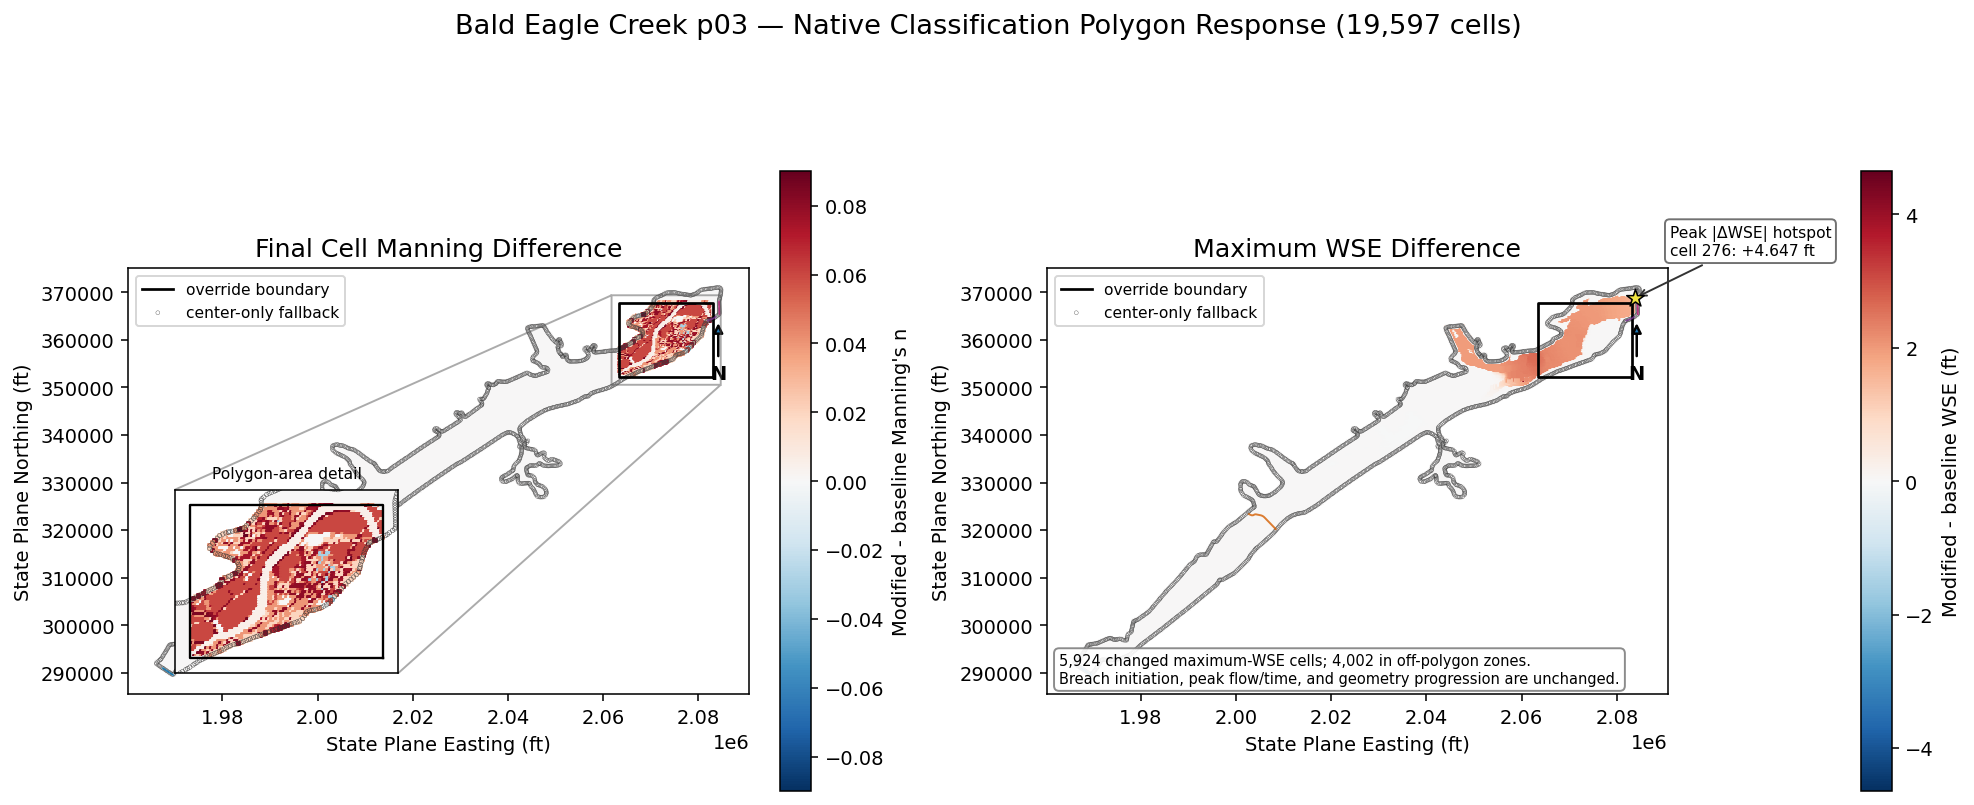

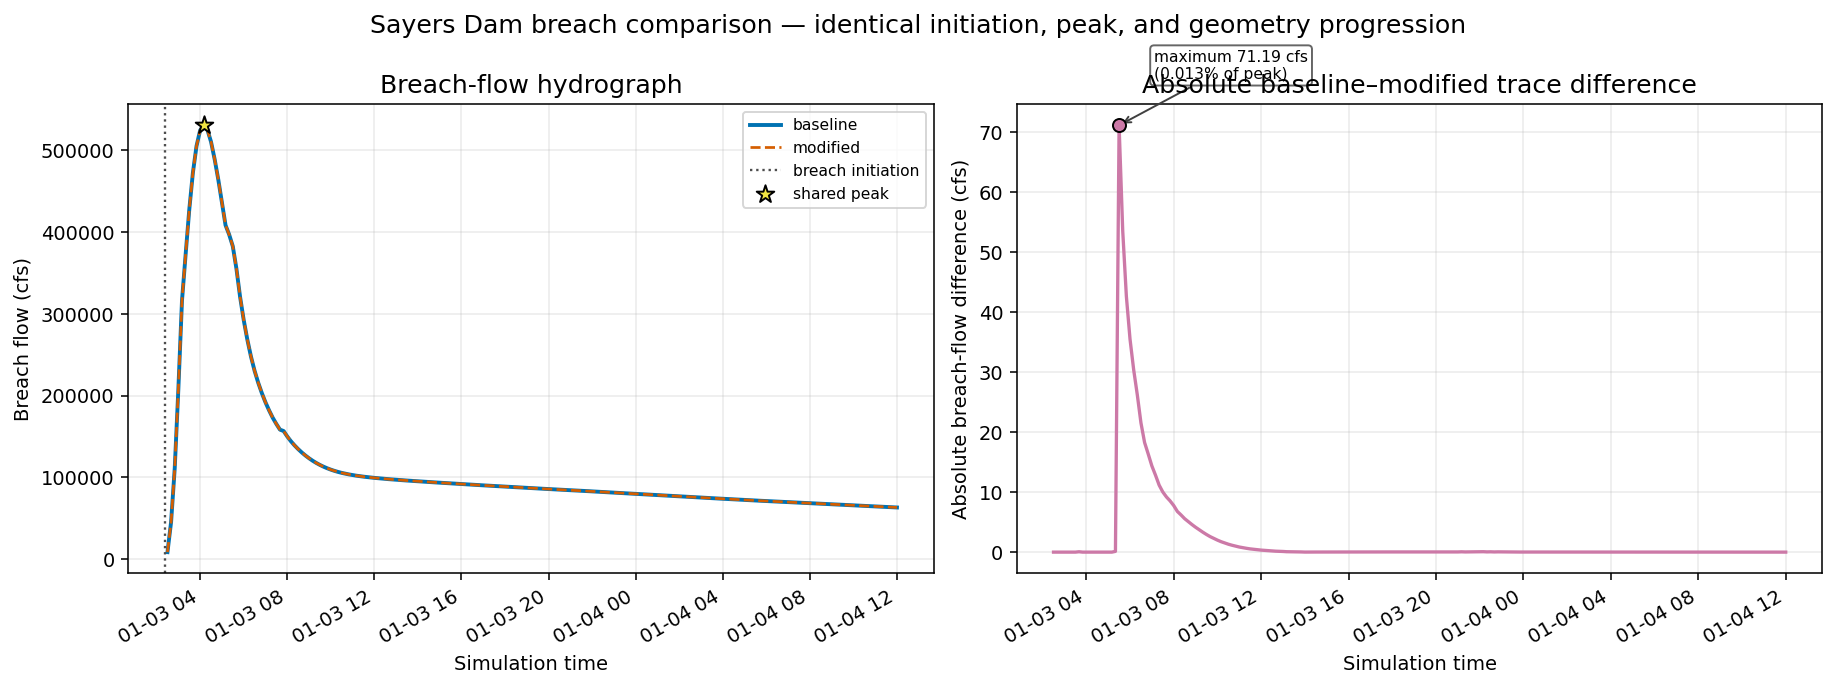

In [10]:
manning_plot_data = comparison.copy()
wse_plot_data = comparison.loc[valid_wse].copy()
n_limit = max(float(manning_plot_data["delta_n"].abs().max()), 0.005)
wse_limit = max(float(wse_plot_data["delta_wse"].abs().max()), 0.01)
n_norm = TwoSlopeNorm(vcenter=0, vmin=-n_limit, vmax=n_limit)
wse_norm = TwoSlopeNorm(vcenter=0, vmin=-wse_limit, vmax=wse_limit)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6.5),
    constrained_layout=True,
)
for ax, data, column, title, label, norm in [
    (
        axes[0],
        manning_plot_data,
        "delta_n",
        "Final Cell Manning Difference",
        "Modified - baseline Manning's n",
        n_norm,
    ),
    (
        axes[1],
        wse_plot_data,
        "delta_wse",
        "Maximum WSE Difference",
        "Modified - baseline WSE (ft)",
        wse_norm,
    ),
]:
    data.plot(
        column=column,
        ax=ax,
        cmap="RdBu_r",
        marker="s",
        markersize=2.5,
        legend=True,
        norm=norm,
        legend_kwds={"label": label, "shrink": 0.72},
    )
    x, y = final_polygon.exterior.xy
    ax.plot(x, y, color="black", linewidth=1.4, label="override boundary")
    fallback_plot = data.loc[
        data["coverage_basis"] == "cell center fallback"
    ]
    ax.scatter(
        fallback_plot.geometry.x,
        fallback_plot.geometry.y,
        s=4,
        facecolors="none",
        edgecolors="0.25",
        linewidths=0.18,
        label="center-only fallback",
    )
    for boundary in bc_lines.itertuples(index=False):
        boundary_x, boundary_y = boundary.geometry.xy
        ax.plot(
            boundary_x,
            boundary_y,
            color=boundary_colors[boundary.Name],
            linewidth=0.9,
            alpha=0.8,
        )
    ax.plot(
        connection_x,
        connection_y,
        color="#D55E00",
        linewidth=1.0,
        alpha=0.8,
    )
    ax.set_title(title)
    ax.set_xlabel("State Plane Easting (ft)")
    ax.set_ylabel("State Plane Northing (ft)")
    ax.set_aspect("equal")
    ax.legend(loc="best")
    ax.annotate(
        "N",
        xy=(0.95, 0.88),
        xytext=(0.95, 0.74),
        xycoords="axes fraction",
        ha="center",
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "linewidth": 1.3},
    )

minx, miny, maxx, maxy = final_polygon.bounds
inset_padding = 0.08 * max(maxx - minx, maxy - miny)
inset = axes[0].inset_axes([0.04, 0.05, 0.43, 0.43])
manning_plot_data.plot(
    column="delta_n",
    ax=inset,
    cmap="RdBu_r",
    marker="s",
    markersize=3.0,
    legend=False,
    norm=n_norm,
)
inset.plot(x, y, color="black", linewidth=1.2)
inset_fallback = manning_plot_data.loc[
    manning_plot_data["coverage_basis"] == "cell center fallback"
]
inset.scatter(
    inset_fallback.geometry.x,
    inset_fallback.geometry.y,
    s=5,
    facecolors="none",
    edgecolors="0.2",
    linewidths=0.22,
)
inset.set_xlim(minx - inset_padding, maxx + inset_padding)
inset.set_ylim(miny - inset_padding, maxy + inset_padding)
inset.set_aspect("equal")
inset.set_title("Polygon-area detail", fontsize=8)
inset.set_xticks([])
inset.set_yticks([])
axes[0].indicate_inset_zoom(inset, edgecolor="0.35")

wse_hotspot = wse_plot_data.loc[
    wse_plot_data["delta_wse"].abs().idxmax()
]
axes[1].scatter(
    [wse_hotspot.geometry.x],
    [wse_hotspot.geometry.y],
    marker="*",
    s=90,
    color="#F0E442",
    edgecolor="black",
    linewidth=0.8,
    zorder=6,
)
axes[1].annotate(
    (
        f"Peak |ΔWSE| hotspot\ncell {int(wse_hotspot['cell_id'])}: "
        f"{wse_hotspot['delta_wse']:+.3f} ft"
    ),
    xy=(wse_hotspot.geometry.x, wse_hotspot.geometry.y),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": "0.2"},
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "0.4",
        "alpha": 0.92,
    },
)
axes[1].text(
    0.02,
    0.02,
    (
        f"{hydraulic_cells:,} changed maximum-WSE cells; "
        f"{off_polygon_hydraulic_cells:,} in off-polygon zones.\n"
        "Breach initiation, peak flow/time, and geometry "
        "progression are unchanged."
    ),
    transform=axes[1].transAxes,
    fontsize=7.5,
    va="bottom",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.5",
        "alpha": 0.9,
    },
)
fig.suptitle(
    (
        "Bald Eagle Creek p03 — Native Classification Polygon "
        "Response (19,597 cells)"
    ),
    fontsize=14,
)
plt.show()

breach_fig, breach_axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    constrained_layout=True,
)
breach_axes[0].plot(
    breach_trace["datetime"],
    breach_trace["breach_flow_baseline"],
    color="#0072B2",
    linewidth=2.0,
    label="baseline",
)
breach_axes[0].plot(
    breach_trace["datetime"],
    breach_trace["breach_flow_modified"],
    color="#D55E00",
    linewidth=1.4,
    linestyle="--",
    label="modified",
)
initiation_time = pd.Timestamp("1999-01-03 02:22:30")
breach_axes[0].axvline(
    initiation_time,
    color="0.3",
    linestyle=":",
    linewidth=1.2,
    label="breach initiation",
)
breach_axes[0].scatter(
    [expected_peak_time],
    [530_807.25],
    marker="*",
    s=90,
    color="#F0E442",
    edgecolor="black",
    zorder=5,
    label="shared peak",
)
breach_axes[0].set_title("Breach-flow hydrograph")
breach_axes[0].set_ylabel("Breach flow (cfs)")
breach_axes[0].set_xlabel("Simulation time")
breach_axes[0].grid(alpha=0.25)
breach_axes[0].legend(loc="best")

breach_axes[1].plot(
    breach_trace["datetime"],
    breach_flow_difference,
    color="#CC79A7",
    linewidth=1.7,
)
breach_axes[1].scatter(
    [max_breach_flow_trace_difference_time],
    [max_breach_flow_trace_difference],
    marker="o",
    s=45,
    color="#CC79A7",
    edgecolor="black",
    zorder=5,
)
breach_axes[1].annotate(
    (
        f"maximum {max_breach_flow_trace_difference:.2f} cfs\n"
        f"({max_breach_flow_trace_difference_percent:.3f}% "
        "of peak)"
    ),
    xy=(
        max_breach_flow_trace_difference_time,
        max_breach_flow_trace_difference,
    ),
    xytext=(18, 24),
    textcoords="offset points",
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": "0.25"},
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "0.4",
    },
)
breach_axes[1].set_title("Absolute baseline–modified trace difference")
breach_axes[1].set_ylabel("Absolute breach-flow difference (cfs)")
breach_axes[1].set_xlabel("Simulation time")
breach_axes[1].grid(alpha=0.25)
breach_fig.suptitle(
    (
        "Sayers Dam breach comparison — identical initiation, "
        "peak, and geometry progression"
    ),
    fontsize=13,
)
breach_fig.autofmt_xdate()
plt.show()


## Conclusions

- Native RASMapper persisted add, update, and delete operations with a
  unique durable backup for every successful mutation.
- A one-member hole-free `MultiPolygon` was normalized; true multipart
  add and interior-ring add/update failed before backup or mutation,
  as verified by unchanged backup inventories and sidecar hashes.
- The class table remained intact after polygon deletion.
- HEC-RAS retained the native `BaldEagleCr` terrain association and
  the exact one-row 2D-area association catalog, recomputed the geometry
  tables, completed both hydraulic solves with the exact
  `HEC-RAS 7.0 April 2026` build, and wrote the required final arrays.
- Checked joins retained all 19,597 Manning cells: 18,066
  polygon-backed cells plus 1,531 explicitly labeled center-only
  fallback cells. Exactly 2,976 final cell Manning values changed, and
  every center-located off-polygon cell remained unchanged.
- Fully covered and center-fallback interior cells resolved to the
  geometry base/regional `Evergreen Forest` values. Non-Manning face
  properties remained materially stable within the native regeneration
  tolerance.
- Exactly 5,924 maximum-WSE values changed, including 4,002 cells in
  off-polygon zones. The unchanged `03JAN1999 02:22:30` breach
  initiation, shared 530,807.25-cfs peak and time, and effectively
  identical breach geometry progression show that these differences
  are nonlinear/local conveyance and peak-response propagation, not a
  breach-timing change. The maximum breach-flow trace difference was
  only about 71.19 cfs (0.013% of peak).
- HEC-RAS 6.0-7.0.1 cannot hydraulically honor classification-polygon
  holes; represent an exclusion by adding explicit, non-overlapping
  hole-free polygons rather than relying on an interior ring.
